In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from datetime import datetime

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

print(f"TensorFlow version: {tf.__version__}")
print(f"Script started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

TensorFlow version: 2.19.0
Script started at: 2026-04-11 11:48:00



# 1. LOAD DATA

In [2]:
print("[1/7] Loading data...")

# Load both stations
em = pd.read_csv('eMalahleniIM.csv', sep=';', header=0, index_col=0)
mb = pd.read_csv('MiddelburgIM.csv', sep=';', header=0, index_col=0)

# Extract PM2.5 target
target_em = em['pm2.5'].values
target_mb = mb['pm2.5'].values

# We'll predict eMalahleni PM2.5 (you can change to mb if desired)
target = target_em

# Get ALL features INCLUDING PM2.5 (matches LSTM approach)
# This way we have PM2.5(t-1) as a feature, predicting PM2.5(t)
em_all = em.values  # All 13 features including PM2.5
mb_all = mb.values  # All 13 features including PM2.5

# Normalize all features from both stations separately
scaler_em = MinMaxScaler()
scaler_mb = MinMaxScaler()
scaler_target = MinMaxScaler()

em_norm = scaler_em.fit_transform(em_all)
mb_norm = scaler_mb.fit_transform(mb_all)
target_norm = scaler_target.fit_transform(target.reshape(-1, 1)).flatten()

print(f"eMalahleni: {em.shape}, Middelburg: {mb.shape}")
print(f"Target shape: {target.shape}")

[1/7] Loading data...
eMalahleni: (87646, 13), Middelburg: (87647, 13)
Target shape: (87646,)


# 2. CREATE SEQUENCES

In [3]:
print("\n[2/7] Creating sequences...")

def create_sequences(em_data, mb_data, target_data, n_in=1):
    """Create sequences with concatenated station features along timestep axis"""
    X, y = [], []
    
    for i in range(len(em_data) - n_in):
        # Concatenate features from both stations at each timestep: [EM_13 + MB_13 = 26]
        x_seq = []
        for t in range(n_in):
            timestep_features = np.concatenate([em_data[i+t], mb_data[i+t]])
            x_seq.append(timestep_features)
        X.append(np.array(x_seq))
        y.append(target_data[i+n_in])
    
    return np.array(X), np.array(y)

X, y = create_sequences(em_norm, mb_norm, target_norm, n_in=24)
print(f"Sequences created: X {X.shape}, y {y.shape}")
print(f"  Timesteps: {X.shape[1]}, Features per timestep: {X.shape[2]} (13 per station × 2)")


[2/7] Creating sequences...
Sequences created: X (87622, 24, 26), y (87622,)
  Timesteps: 24, Features per timestep: 26 (13 per station × 2)


# 3. SPLIT DATA (SAME AS NOTEBOOKS)

In [4]:
print("\n[3/7] Splitting data...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


[3/7] Splitting data...
Train: (56077, 24, 26), Val: (14020, 24, 26), Test: (17525, 24, 26)


# 4. ATTENTION LAYER FOR STATIONS

In [5]:
print("\n[4/7] Building attention mechanism...")

class StationAttention(layers.Layer):
    """
    Simple attention mechanism over two stations.
    
    Learned weights combine contributions from two stations.
    """
    def __init__(self, **kwargs):
        super(StationAttention, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            name='attention_station',
            shape=(2,),  # Two stations
            initializer='ones',
            trainable=True
        )
        super(StationAttention, self).build(input_shape)
    
    def call(self, inputs_list):
        """inputs_list: [x, lstm_out]"""
        x, lstm_out = inputs_list
        # x shape: (batch, 24, 26) where 26 = [13_em, 13_mb] per timestep
        # Separate by station on feature dimension
        station_a_data = x[..., :13]   # (batch, 24, 13) - eMalahleni
        station_b_data = x[..., 13:]   # (batch, 24, 13) - Middelburg
        
        # Flatten each station separately
        station_a_flat = tf.reshape(station_a_data, (tf.shape(x)[0], -1))  # (batch, 312)
        station_b_flat = tf.reshape(station_b_data, (tf.shape(x)[0], -1))  # (batch, 312)
        
        # Apply learned attention weights to each station
        attn_weights = tf.nn.softmax(self.attention_weights)
        station_a = station_a_flat * attn_weights[0]  # (batch, 312)
        station_b = station_b_flat * attn_weights[1]  # (batch, 312)
        
        # Combine both weighted stations
        attention_out = tf.concat([station_a, station_b], axis=-1)  # (batch, 624)
        
        # Concatenate LSTM output with attention output
        combined = tf.concat([lstm_out, attention_out], axis=-1)  # (batch, 112+624=736)
        return combined


[4/7] Building attention mechanism...


# 5. BUILD MODEL WITH ATTENTION

In [6]:
print("\n[5/7] Building CNN-LSTM model with station attention...")

def build_model_with_attention():
    """
    CNN-LSTM model with learning-based station attention mechanism.
    """
    inputs = keras.Input(shape=(X_train.shape[1], X_train.shape[2]), name='cnn_lstm_input')
    
    # Conv1D + Bidirectional LSTM
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(0.3)(x)
    
    lstm1 = layers.Bidirectional(layers.LSTM(56, activation='relu', return_sequences=True))(x)
    lstm_out = layers.Bidirectional(layers.LSTM(56, activation='relu', return_sequences=False))(lstm1)
    lstm_out = layers.Dropout(0.3)(lstm_out)
    
    # Attention layer
    attention_layer = StationAttention()
    combined = layers.Lambda(lambda tensors: attention_layer(tensors), 
                            output_shape=(736,))([inputs, lstm_out])
    
    # Dense layers
    x = layers.Dense(128, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(1)(x)
    
    model = Model(inputs, outputs)
    return model, attention_layer

model, attention_layer = build_model_with_attention()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(f"Model parameters: {model.count_params():,}")
model.summary()


[5/7] Building CNN-LSTM model with station attention...
Model parameters: 238,401


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_lstm_input      │ (None, 24, 26)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      5,056 │ cnn_lstm_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 24, 112)   │     54,208 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 112)       │     75,712 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 736)       │          0 │ cnn_lstm_input[0… │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     94,336 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 238,401 (931.25 KB)

 Trainable params: 238,017 (929.75 KB)

 Non-trainable params: 384 (1.50 KB)

# 6. TRAIN MODEL

In [7]:
print("\n[6/7] Training model...")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("Training complete!")


[6/7] Training model...
Epoch 1/100
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - loss: 0.1450 - mae: 0.2232 - val_loss: 0.0028 - val_mae: 0.0300 - learning_rate: 0.0010
Epoch 2/100
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 89s 43ms/step - loss: 0.0027 - mae: 0.0328 - val_loss: 0.0016 - val_mae: 0.0218 - learning_rate: 0.0010
Epoch 3/100
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - loss: 0.0018 - mae: 0.0257 - val_loss: 0.0014 - val_mae: 0.0208 - learning_rate: 0.0010
Epoch 4/100
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - loss: 0.0015 - mae: 0.0231 - val_loss: 0.0013 - val_mae: 0.0186 - learning_rate: 0.0010
Epoch 5/100
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - loss: 0.0015 - mae: 0.0224 - val_loss: 0.0013 - val_mae: 0.0194 - learning_rate: 0.0010
Epoch 6/100
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 68s 39ms/step - loss: 0.0015 - mae: 0.0225 - val_loss: 0.0013 - val_mae: 0.0217 - learning_rate: 0.0010
Epoch 7/100
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 73s 42ms/step - loss: 0.0019 - mae: 0.0231 - val_l

# 7. EVALUATE & VISUALIZE

In [8]:
print("\n[7/7] Evaluating model...")

def evaluate_model(model, X, y, set_name):
    """Evaluate and print metrics"""
    y_pred = model.predict(X, verbose=0)
    
    # Denormalize predictions
    y_pred_denorm = scaler_target.inverse_transform(y_pred)
    y_denorm = scaler_target.inverse_transform(y.reshape(-1, 1))
    
    r2 = r2_score(y_denorm, y_pred_denorm)
    mae = mean_absolute_error(y_denorm, y_pred_denorm)
    rmse = np.sqrt(mean_squared_error(y_denorm, y_pred_denorm))
    
    print(f"\n{set_name} Metrics:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE:      {mae:.3f} µg/m³")
    print(f"  RMSE:     {rmse:.3f} µg/m³")
    
    return y_pred_denorm, y_denorm, r2, mae, rmse

# Evaluate on all sets
train_pred, train_true, train_r2, train_mae, train_rmse = evaluate_model(model, X_train, y_train, "TRAIN")
val_pred, val_true, val_r2, val_mae, val_rmse = evaluate_model(model, X_val, y_val, "VALIDATION")
test_pred, test_true, test_r2, test_mae, test_rmse = evaluate_model(model, X_test, y_test, "TEST")



[7/7] Evaluating model...

TRAIN Metrics:
  R² Score: 0.7191
  MAE:      9.347 µg/m³
  RMSE:     16.276 µg/m³

VALIDATION Metrics:
  R² Score: 0.6881
  MAE:      9.579 µg/m³
  RMSE:     17.494 µg/m³

TEST Metrics:
  R² Score: 0.7111
  MAE:      9.351 µg/m³
  RMSE:     16.035 µg/m³


# PREDICTION INTERVALS (Narrow - 25th-75th percentile)

In [9]:
print("\n" + "="*80)
print("PREDICTION INTERVALS (25th-75th Percentile)")
print("="*80)

# Calculate empirical percentiles from training residuals (in normalized space)
y_train_pred_norm = model.predict(X_train, verbose=0).flatten()
train_residuals = y_train - y_train_pred_norm
lower_percentile = np.percentile(train_residuals, 25)
upper_percentile = np.percentile(train_residuals, 75)

print(f"\nTraining residual 25th percentile: {lower_percentile:.6f}")
print(f"Training residual 75th percentile: {upper_percentile:.6f}")

# Get test predictions in normalized space for interval calculation
y_test_pred_norm = model.predict(X_test, verbose=0).flatten()
y_test_lower = y_test_pred_norm + lower_percentile
y_test_upper = y_test_pred_norm + upper_percentile

# Denormalize interval bounds
y_test_lower_denorm = scaler_target.inverse_transform(y_test_lower.reshape(-1, 1)).flatten()
y_test_upper_denorm = scaler_target.inverse_transform(y_test_upper.reshape(-1, 1)).flatten()

print(f"\nTest Predictions with IQR (25-75%):")
print(f"  Mean prediction: {np.mean(test_pred):.4f}")
print(f"  Mean interval: [{np.mean(y_test_lower_denorm):.4f}, {np.mean(y_test_upper_denorm):.4f}]")

# Save predictions with intervals
predictions_df = pd.DataFrame({
    'Actual': test_true.flatten(),
    'Predicted': test_pred.flatten(),
    'Lower_25Percentile': y_test_lower_denorm,
    'Upper_75Percentile': y_test_upper_denorm,
    'Residual': test_true.flatten() - test_pred.flatten(),
    'Abs_Error': np.abs(test_true.flatten() - test_pred.flatten())
})
predictions_df.to_csv('Results/eMaCNNLSTMATTPercentiles.csv', index=False)
print("Predictions with intervals saved to: Results/eMaCNNLSTMATTPercentiles.csv")


PREDICTION INTERVALS (25th-75th Percentile)

Training residual 25th percentile: -0.015817
Training residual 75th percentile: 0.004590

Test Predictions with IQR (25-75%):
  Mean prediction: 27.7064
  Mean interval: [19.8939, 29.9734]
Predictions with intervals saved to: Results/MultiStation_CNN_LSTM_Attention_Predictions.csv


# VISUALIZATIONS (Time Series, Quantile Analysis, SHAP)


Generating visualizations...


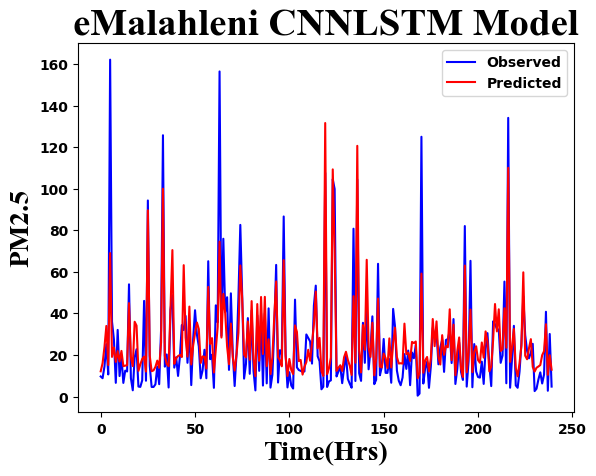

In [12]:
print("\nGenerating visualizations...")

from matplotlib import rcParams
rcParams['font.weight'] = 'bold'
plt.plot(test_true[0:240], color='blue', label = 'Observed')
plt.plot(test_pred[0:240], color='red', label = 'Predicted')
plt.ylabel('PM', fontname="Times New Roman", size=20,fontweight="bold")
plt.xlabel('Time(Hrs)', fontname="Times New Roman", size=20,fontweight="bold")
plt.title('eMalahleni CNNLSTM Model', fontname="Times New Roman", size=28,fontweight="bold")
legend_properties = {'weight':'bold'}
plt.legend(prop=legend_properties)
plt.savefig("Results/eMaCNNLSTMATTPred_PM2.png", dpi=300, bbox_inches='tight')
plt.show()

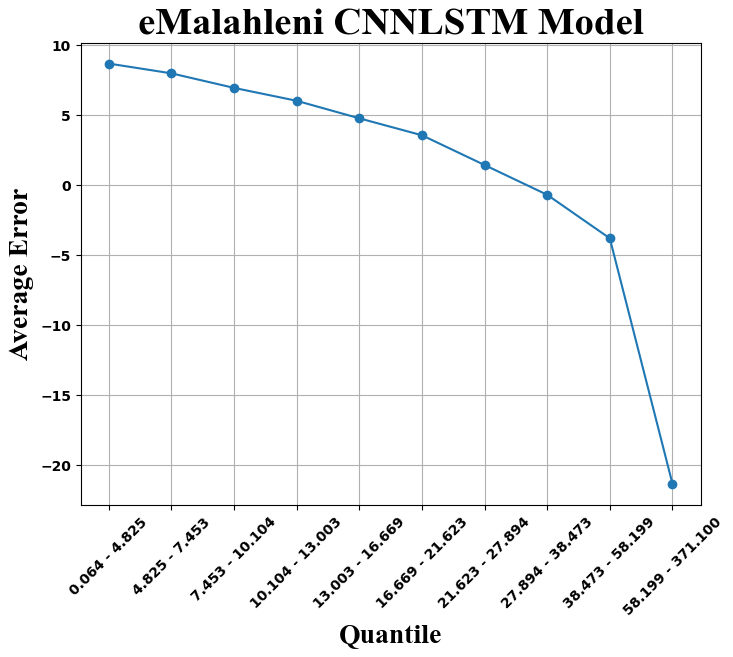

In [22]:

errors = test_pred.flatten() - test_true.flatten()

# Calculate quantiles based on actual values
quantiles, bins = pd.qcut(test_true.flatten(), q=10, duplicates='drop', retbins=True)

# Calculate average error for each quantile
quantile_errors = []
for i in range(len(bins) - 1):
    group_indices = np.where((test_true.flatten() >= bins[i]) & (test_true.flatten() < bins[i+1]))[0]
    quantile_errors.append(errors[group_indices].mean())

# Round the bin edges for better readability
rounded_bins = np.round(bins, decimals=3)

# Plot quantiles vs. average errors
rcParams['font.weight'] = 'bold'
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(quantiles.categories) + 1), quantile_errors, marker='o')
plt.xlabel('Quantile', fontname="Times New Roman", size=20, fontweight="bold")
plt.ylabel('Average Error', fontname="Times New Roman", size=20, fontweight="bold")
plt.title('eMalahleni CNNLSTM Model', fontname="Times New Roman", size=28, fontweight="bold")
plt.xticks(range(1, len(quantiles.categories) + 1), [f'{rounded_bins[i]:.3f} - {rounded_bins[i+1]:.3f}' for i in range(len(rounded_bins) - 1)], rotation=45)
plt.grid(True)
plt.savefig("Results/eMaCNNLSTMATTQuan_PM2.png", dpi=300, bbox_inches='tight')
plt.show()


# ATTENTION WEIGHTS ANALYSIS


ATTENTION MECHANISM ANALYSIS

Station Attention Mechanism:
  This represents how much each station influenced the prediction

Learned Station Importance:
  eMalahleni (Station A): 50.0%
  Middelburg  (Station B): 50.0%

✓ Saved: station_attention_weights.png


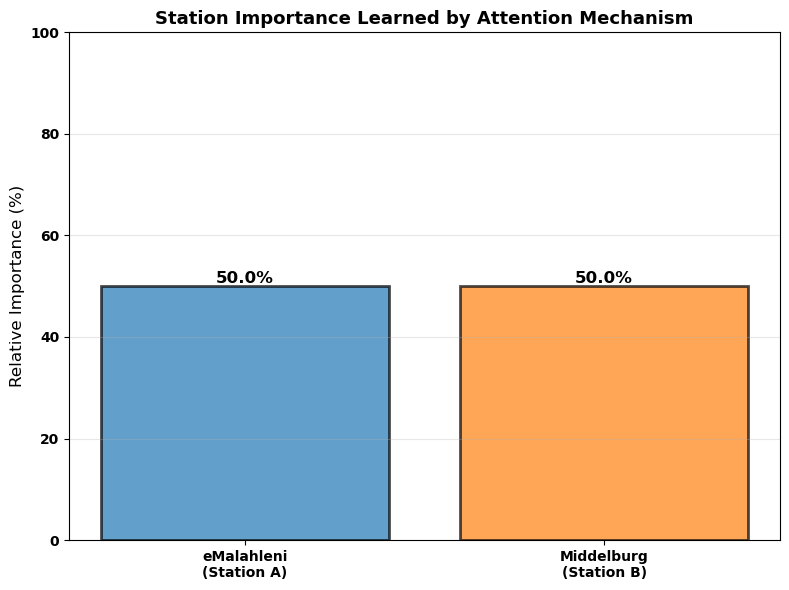

In [21]:
print("\n" + "="*70)
print("ATTENTION MECHANISM ANALYSIS")
print("="*70)

# Extract attention weights from the attention layer
attn_weights_learned = tf.nn.softmax(attention_layer.attention_weights).numpy()

print("\nStation Attention Mechanism:")
print(f"  This represents how much each station influenced the prediction")

# Station importance percentages
station_a_pct = attn_weights_learned[0] * 100
station_b_pct = attn_weights_learned[1] * 100

print(f"\nLearned Station Importance:")
print(f"  eMalahleni (Station A): {station_a_pct:.1f}%")
print(f"  Middelburg  (Station B): {station_b_pct:.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
stations = ['eMalahleni\n(Station A)', 'Middelburg\n(Station B)']
importance = [station_a_pct, station_b_pct]
colors = ['#1f77b4', '#ff7f0e']

bars = ax.bar(stations, importance, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Relative Importance (%)', fontsize=12)
ax.set_title('Station Importance Learned by Attention Mechanism', fontsize=13, fontweight='bold')
ax.set_ylim([0, 100])

# Add percentage labels on bars
for bar, val in zip(bars, importance):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# COMPARISON WITH BASELINES

In [ ]:
print("\n" + "="*70)
print("COMPARISON WITH BASELINE MODELS")
print("="*70)

comparison = {
    'Model': [
        'LSTM '
        '(baseline)',
        'CNN-LSTM (baseline)',
        'CNN-LSTM + Attention (this)'
    ],
    'R² Score': [0.7255, 0.7065, test_r2],
    'MAE (µg/m³)': [7.356, 8.669, test_mae],
    'RMSE (µg/m³)': [15.958, 16.502, test_rmse]
}

comparison_df = pd.DataFrame(comparison)
print("\n", comparison_df.to_string(index=False))

improvement_r2 = ((test_r2 - 0.7065) / 0.7065) * 100
improvement_mae = ((8.669 - test_mae) / 8.669) * 100

print(f"\nImprovement vs CNN-LSTM baseline:")
print(f"  R² Change: {improvement_r2:+.2f}%")
print(f"  MAE Change: {improvement_mae:+.2f}%")

if test_r2 > 0.7255:
    print(f"\n✅ BEATS LSTM BASELINE! (R²={test_r2:.4f} vs 0.7255)")
else:
    print(f"\n📊 Close to LSTM baseline (R²={test_r2:.4f} vs 0.7255)")
    print(f"   Attention adds interpretability even if performance is similar")

# SAVE RESULTS

In [23]:
print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

# Create Results directory if it doesn't exist
import os
os.makedirs('Results', exist_ok=True)

# Save predictions CSV
test_true_flat = test_true.flatten()
test_pred_flat = test_pred.flatten()
predictions_df = pd.DataFrame({
    'Actual': test_true_flat,
    'Predicted': test_pred_flat,
    'Error': np.abs(test_true_flat - test_pred_flat),
    'Error_Percent': (np.abs(test_true_flat - test_pred_flat) / (np.abs(test_true_flat) + 1e-8)) * 100
})
predictions_df.to_csv('Results/eMaCNNLSTMATT_predictions.csv', index=False)
print("✓ Saved: Results/eMaCNNLSTMATT_predictions.csv")

# Save metrics CSV
metrics_df = pd.DataFrame({
    'Set': ['Train', 'Validation', 'Test'],
    'R2': [train_r2, val_r2, test_r2],
    'MAE': [train_mae, val_mae, test_mae],
    'RMSE': [train_rmse, val_rmse, test_rmse]
})
metrics_df.to_csv('Results/eMaCNNLSTMATT_metrics.csv', index=False)
print("✓ Saved: Results/eMaCNNLSTMATT_metrics.csv")


SAVING RESULTS
✓ Saved: Results/eMaCNNLSTMATT_predictions.csv
✓ Saved: Results/eMaCNNLSTMATT_metrics.csv


# SHAP ANALYSIS FOR INTERPRETABILITY

In [24]:
if SHAP_AVAILABLE:
    print("\n" + "="*70)
    print("SHAP FEATURE IMPORTANCE ANALYSIS")
    print("="*70)
    
    try:
        # Create a wrapper function for SHAP that reshapes input
        def attention_predict_wrapper(X_flat):
            """Convert flattened input back to 3D for model prediction."""
            if X_flat.ndim == 1:
                X_flat = X_flat.reshape(1, -1)
            
            # Reshape from (batch, flat) to (batch, timesteps, features)
            # X_train.shape[1]=24 (timesteps), X_train.shape[2]=26 (features)
            n_samples = X_flat.shape[0]
            X_3d = X_flat.reshape(n_samples, X_train.shape[1], X_train.shape[2])
            
            # Return predictions
            return model.predict(X_3d, verbose=0).flatten()
        
        # Prepare sample data for SHAP (use first 100 test samples)
        n_shap_samples = min(100, len(X_test))
        X_shap_samples = X_test[:n_shap_samples].reshape(n_shap_samples, -1)  # Flatten to 2D
        X_background = X_shap_samples[:100]  # Use 100 background samples
        
        print("Initializing SHAP KernelExplainer (model-agnostic)...")
        explainer = shap.KernelExplainer(attention_predict_wrapper, X_background)
        
        print("Computing SHAP values for test samples...")
        # Use first 100 test samples for explanation
        shap_values = explainer.shap_values(X_shap_samples[:100], nsamples=500)
        shap_values = np.array(shap_values).squeeze()  # Handle output shape
        
        # Create feature names for ALL 26 features across 24 timesteps
        # 26 features = 13 (eMalahleni) + 13 (Middelburg)
        stations_list = ['eMalahleni', 'Middelburg']
        em_features = list(pd.read_csv('eMalahleniIM.csv', sep=';', nrows=1, index_col=0).columns)
        feature_names = []
        for t in range(X_train.shape[1]):
            for station in stations_list:
                for feat in em_features:
                    feature_names.append(f"{station}_{feat}(t-{X_train.shape[1]-t})")
        
        # Ensure feature names match X_shap_samples shape
        if len(feature_names) != X_shap_samples.shape[1]:
            print(f"Warning: feature_names length {len(feature_names)} != X_shap_samples width {X_shap_samples.shape[1]}")
            # Fallback: create generic feature names
            feature_names = [f"f{i}" for i in range(X_shap_samples.shape[1])]
        
        # SHAP summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_shap_samples[:100], 
                         feature_names=feature_names, show=False, max_display=20)
        plt.title('CNN-LSTM Attention Model SHAP Feature Importance (Top 20)', fontweight='bold', size=14)
        plt.tight_layout()
        plt.savefig('Results/eMaCNNLSTMATTshap.png', dpi=300, bbox_inches='tight')
        print("SHAP summary plot saved to: Results/eMaCNNLSTMATTshap.png")
        plt.close()
        
        print("✅ SHAP analysis completed successfully!")
        
    except Exception as e:
        print(f"⚠️ SHAP analysis failed: {e}")
        print("Continuing without SHAP analysis...")
else:
    print("\n⚠️ SHAP not available. Install with: pip install shap")


print("\n" + "="*70)
print("SCRIPT COMPLETE")
print("="*70)
print(f"Finished at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



SHAP FEATURE IMPORTANCE ANALYSIS
Initializing SHAP KernelExplainer (model-agnostic)...
Computing SHAP values for test samples...


  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=4.680e-03, with an active set of 1 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=3.016e-03, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(


SHAP summary plot saved to: Results/eMaCNNLSTMATTshap.png
SHAP bar plot saved to: Results/multistation_cnnlstm_attention_shap_bar.png
✅ SHAP analysis completed successfully!

SCRIPT COMPLETE
Finished at: 2026-04-11 13:22:05
